In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import gamma
from scipy.stats import weibull_min
from scipy.stats import nbinom
import pyro

c:\Users\annas\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Exploratory Data Analysis - Train dataset

Download original train dataset

In [2]:
df_original=pd.read_csv("data/train.csv")
df_original.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


Select relevant variables and save the new dataset

In [3]:
df_train = df_original[["MONTH", "DAY_OF_WEEK", "DEP_DEL15", "CONCURRENT_FLIGHTS", "CARRIER_NAME", "PRCP", "AWND", "DEPARTING_AIRPORT","DEP_TIME_BLK", "LATITUDE", "LONGITUDE"]]
df_train = df_train.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})
df_train.to_csv("data/train_filter.csv", index=False)
print(f"Number of observations: {len(df_train)}")
df_train.head()

Number of observations: 4542343


,MONTH,DAY_OF_WEEK,DELAY,CONCURRENT_FLIGHTS,CARRIER_NAME,PRCP,WIND,DEPARTING_AIRPORT,DEP_TIME_BLK,LATITUDE,LONGITUDE
0,7,7,0,26,American Airlines Inc.,0.00,4.25,Douglas Municipal,1500-1559,35.219,-80.936
1,4,1,0,63,SkyWest Airlines Inc.,0.00,11.41,Stapleton International,1300-1359,39.774,-104.880
2,11,4,0,3,American Eagle Airlines Inc.,0.00,0.45,Adams Field,0001-0559,34.729,-92.234
3,3,2,0,14,Southwest Airlines Co.,0.00,8.05,San Diego International Lindbergh Fl,1500-1559,32.733,-117.187
4,7,3,0,85,American Eagle Airlines Inc.,0.01,10.51,Chicago O'Hare International,0800-0859,41.978,-87.906


Download new dataset and check for missing values

In [4]:
df_train=pd.read_csv("data/train_filter.csv")
print(df_train.isna().sum())

MONTH                 0
DAY_OF_WEEK           0
DELAY                 0
CONCURRENT_FLIGHTS    0
CARRIER_NAME          0
PRCP                  0
WIND                  0
DEPARTING_AIRPORT     0
DEP_TIME_BLK          0
LATITUDE              0
LONGITUDE             0
dtype: int64


## 1.2. Categorical Variables

### Month

In [5]:
df_train["MONTH"].value_counts().sort_index()

MONTH
1     351390
2     315785
3     387505
4     373800
5     390479
6     389812
7     404984
8     406093
9     370721
10    393106
11    372259
12    386409
Name: count, dtype: int64

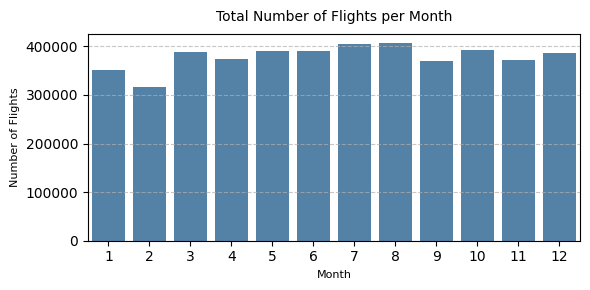

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 3))
sns.countplot(
    data=df_train, 
    x='MONTH', 
    color='steelblue'
)

plt.title('Total Number of Flights per Month', fontsize=10, pad=9)
plt.xlabel('Month', fontsize=8)
plt.ylabel('Number of Flights', fontsize=8)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

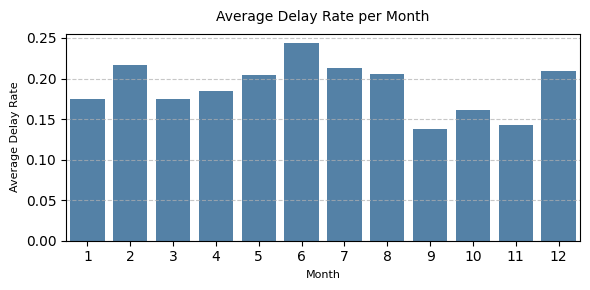

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 3))

sns.barplot(
    data=df_train, 
    x='MONTH', 
    y='DELAY', 
    color='steelblue',
    errorbar=None  # Removes the little error lines at the top of bars for a cleaner look
)

plt.title('Average Delay Rate per Month', fontsize=10, pad=9)
plt.xlabel('Month', fontsize=8)
plt.ylabel('Average Delay Rate', fontsize=8)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Day of Week

In [8]:
df_train["DAY_OF_WEEK"].value_counts().sort_index()

DAY_OF_WEEK
1    676815
2    662339
3    656193
4    669146
5    678895
6    552926
7    646029
Name: count, dtype: int64

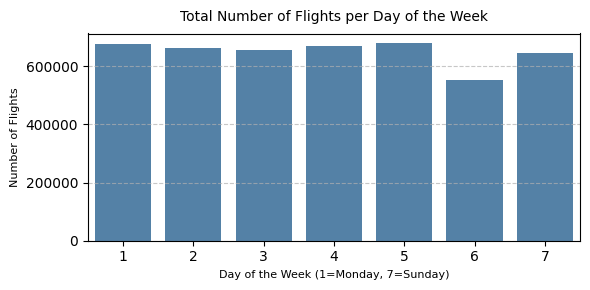

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 3))
sns.countplot(
    data=df_train, 
    x='DAY_OF_WEEK', 
    color='steelblue'
)

plt.title('Total Number of Flights per Day of the Week', fontsize=10, pad=9)
plt.xlabel('Day of the Week (1=Monday, 7=Sunday)', fontsize=8) 
plt.ylabel('Number of Flights', fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

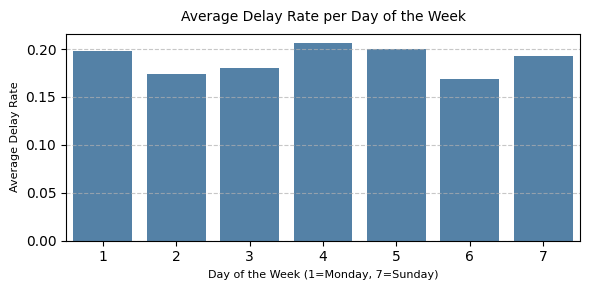

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 3))

sns.barplot(
    data=df_train, 
    x='DAY_OF_WEEK', 
    y='DELAY', 
    color='steelblue',
    errorbar=None  # Removes the error lines for a cleaner look
)
plt.title('Average Delay Rate per Day of the Week', fontsize=10, pad=9)
plt.xlabel('Day of the Week (1=Monday, 7=Sunday)', fontsize=8)
plt.ylabel('Average Delay Rate', fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Delay (Class)

Classes are not balanced

In [11]:
df_train["DELAY"].value_counts().sort_index()

DELAY
0    3683185
1     859158
Name: count, dtype: int64

### Departure Time Block

In [12]:
df_train["DEP_TIME_BLK"].value_counts().sort_index()

DEP_TIME_BLK
0001-0559    103919
0600-0659    301102
0700-0759    305250
0800-0859    316638
0900-0959    277141
1000-1059    278453
1100-1159    276573
1200-1259    278535
1300-1359    246927
1400-1459    262992
1500-1559    272066
1600-1659    258052
1700-1759    285923
1800-1859    262689
1900-1959    250556
2000-2059    239462
2100-2159    154672
2200-2259    135882
2300-2359     35511
Name: count, dtype: int64

--- Flight Volume Statistics per Time Block ---
Average flights per block: 239,071
Maximum flights: 316,638 (During 0800-0859)
Minimum flights: 35,511 (During 2300-2359)


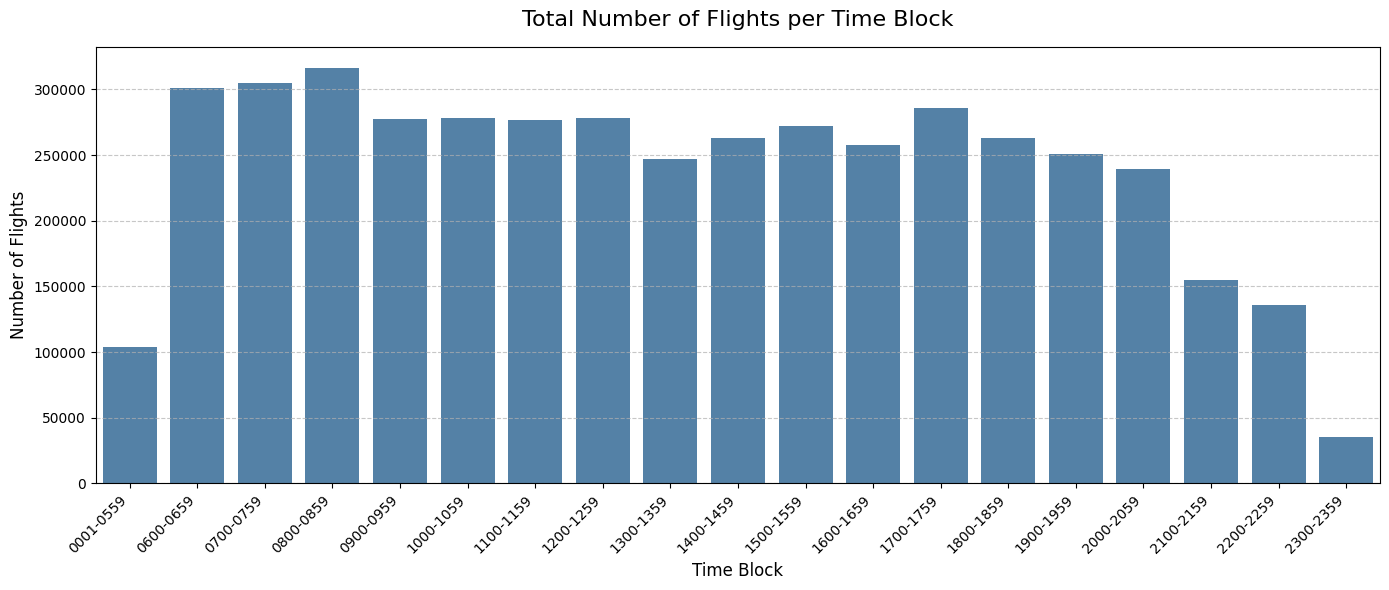

In [13]:
flight_counts = df_train['DEP_TIME_BLK'].value_counts()
mean_flights = flight_counts.mean()
max_flights = flight_counts.max()
min_flights = flight_counts.min()

busiest_block = flight_counts.idxmax()
quietest_block = flight_counts.idxmin()

# Extract and sort the time blocks chronologically instead of by frequency
time_order = sorted(df_train['DEP_TIME_BLK'].dropna().unique())

print("--- Flight Volume Statistics per Time Block ---")
print(f"Average flights per block: {mean_flights:,.0f}")
print(f"Maximum flights: {max_flights:,} (During {busiest_block})")
print(f"Minimum flights: {min_flights:,} (During {quietest_block})")

plt.figure(figsize=(14, 6))

sns.countplot(
    data=df_train, 
    x='DEP_TIME_BLK', 
    order=time_order, 
    color='steelblue'
),

plt.title('Total Number of Flights per Time Block', fontsize=16, pad=15)
plt.xlabel('Time Block', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

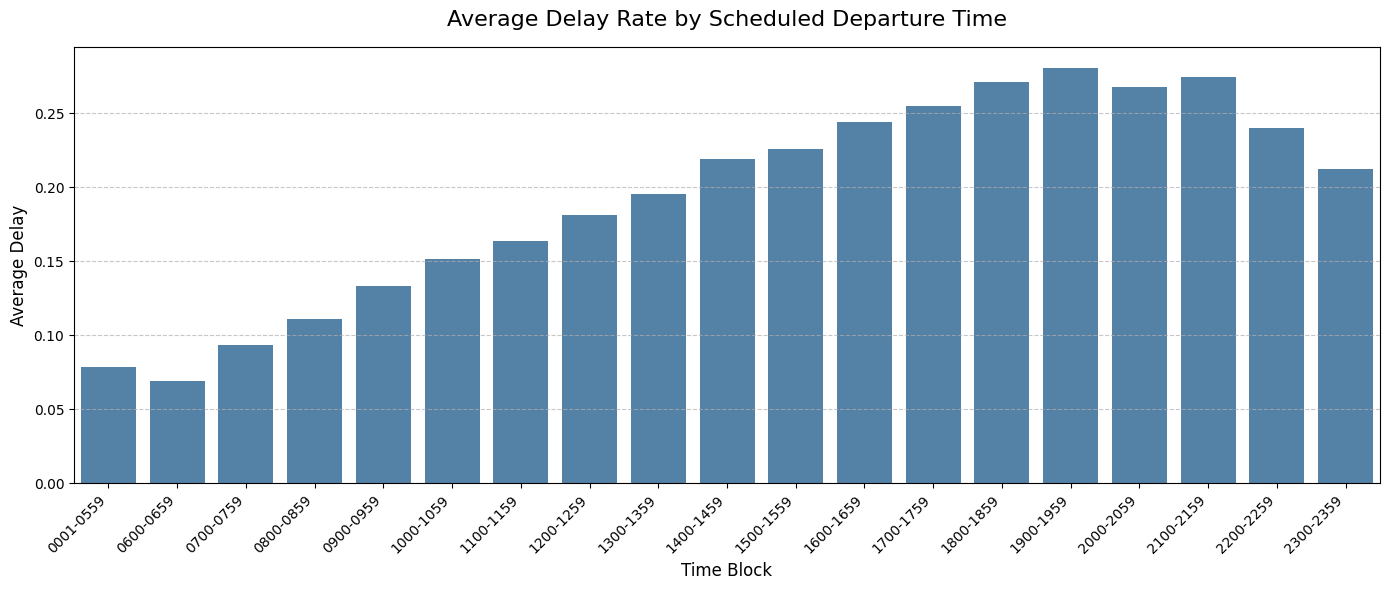

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract and sort the time blocks chronologically, preventing to sort by frequency instead of time
time_order = sorted(df_train['DEP_TIME_BLK'].dropna().unique())

plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_train, 
    x='DEP_TIME_BLK', 
    y='DELAY', 
    order=time_order, 
    color='steelblue', 
    errorbar=None
)

plt.title('Average Delay Rate by Scheduled Departure Time', fontsize=16, pad=15)
plt.xlabel('Time Block', fontsize=12)
plt.ylabel('Average Delay', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

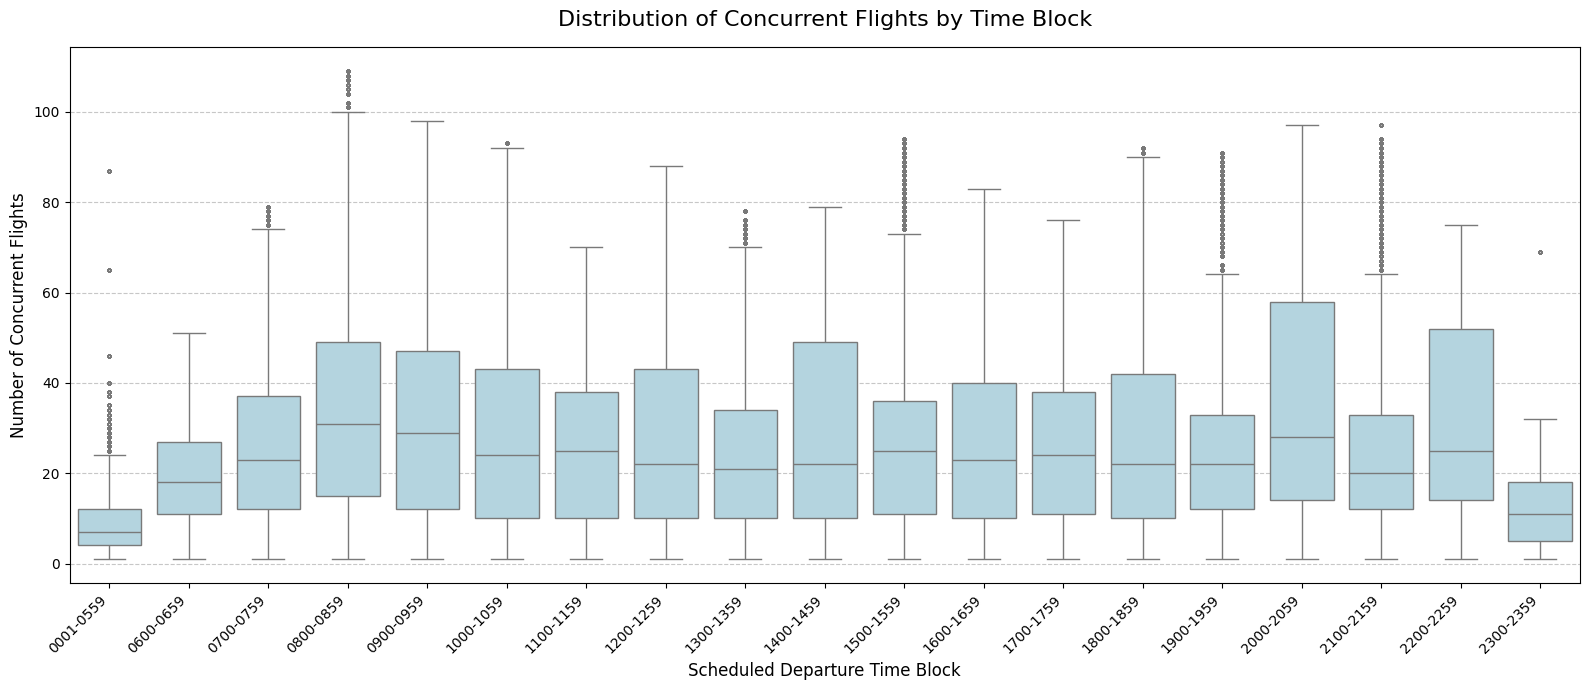

In [15]:
plt.figure(figsize=(16, 7))

sns.boxplot(
    data=df_train, 
    x='DEP_TIME_BLK', 
    y='CONCURRENT_FLIGHTS', 
    order=time_order, 
    color='lightblue',
    fliersize=2  # Makes outlier dots a bit smaller so they don't clutter the graph
)
plt.title('Distribution of Concurrent Flights by Time Block', fontsize=16, pad=15)
plt.xlabel('Scheduled Departure Time Block', fontsize=12)
plt.ylabel('Number of Concurrent Flights', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Carrier

In [16]:
print(f"Number of airlines: {len(df_train['CARRIER_NAME'].unique())}")
df_train["CARRIER_NAME"].value_counts()

Number of airlines: 17


CARRIER_NAME
Southwest Airlines Co.          907076
Delta Air Lines Inc.            657062
American Airlines Inc.          632771
United Air Lines Inc.           420624
SkyWest Airlines Inc.           409126
Midwest Airline, Inc.           210298
JetBlue Airways                 188402
Alaska Airlines Inc.            167595
American Eagle Airlines Inc.    160390
Comair Inc.                     153365
Endeavor Air Inc.               142498
Spirit Air Lines                132678
Mesa Airlines Inc.              124171
Frontier Airlines Inc.           84970
Atlantic Southeast Airlines      69161
Hawaiian Airlines Inc.           52444
Allegiant Air                    29712
Name: count, dtype: int64

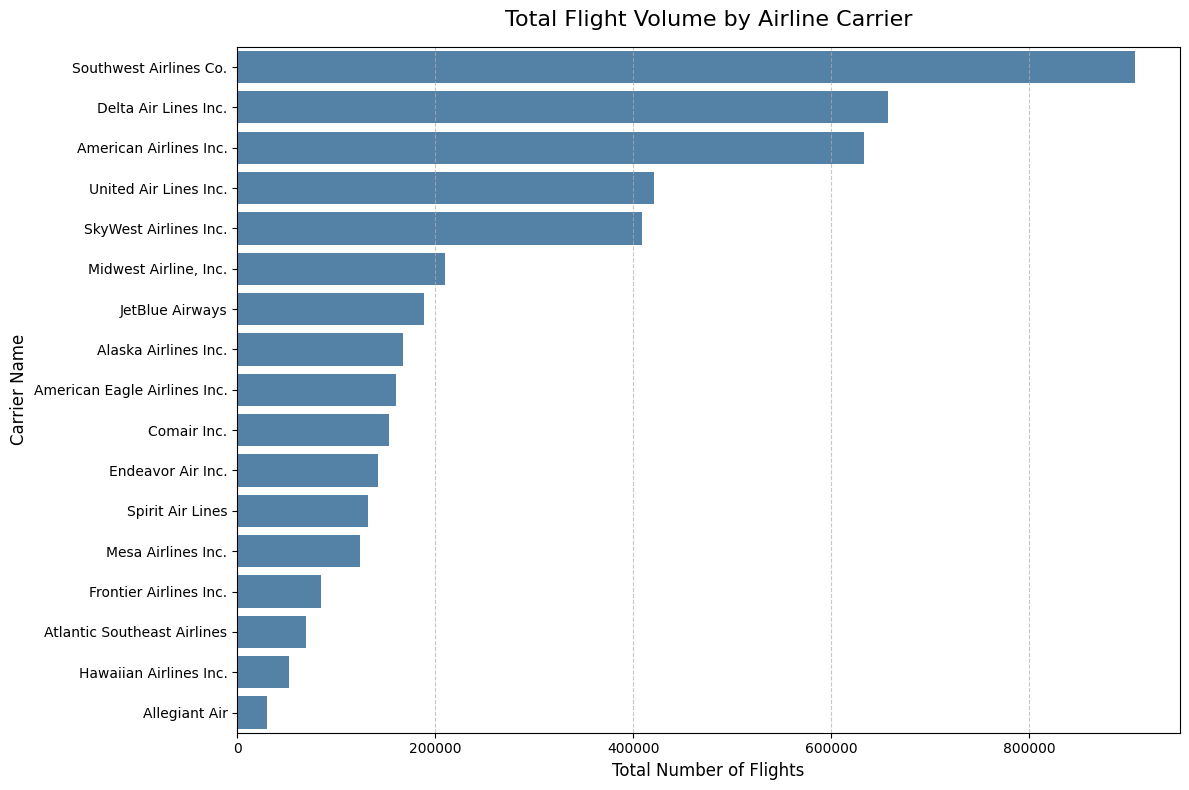

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
carrier_volume_order = df_train['CARRIER_NAME'].value_counts().index
sns.countplot(
    data=df_train, 
    y='CARRIER_NAME', 
    order=carrier_volume_order, 
    color='steelblue'
)

plt.title('Total Flight Volume by Airline Carrier', fontsize=16, pad=15)
plt.xlabel('Total Number of Flights', fontsize=12)
plt.ylabel('Carrier Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

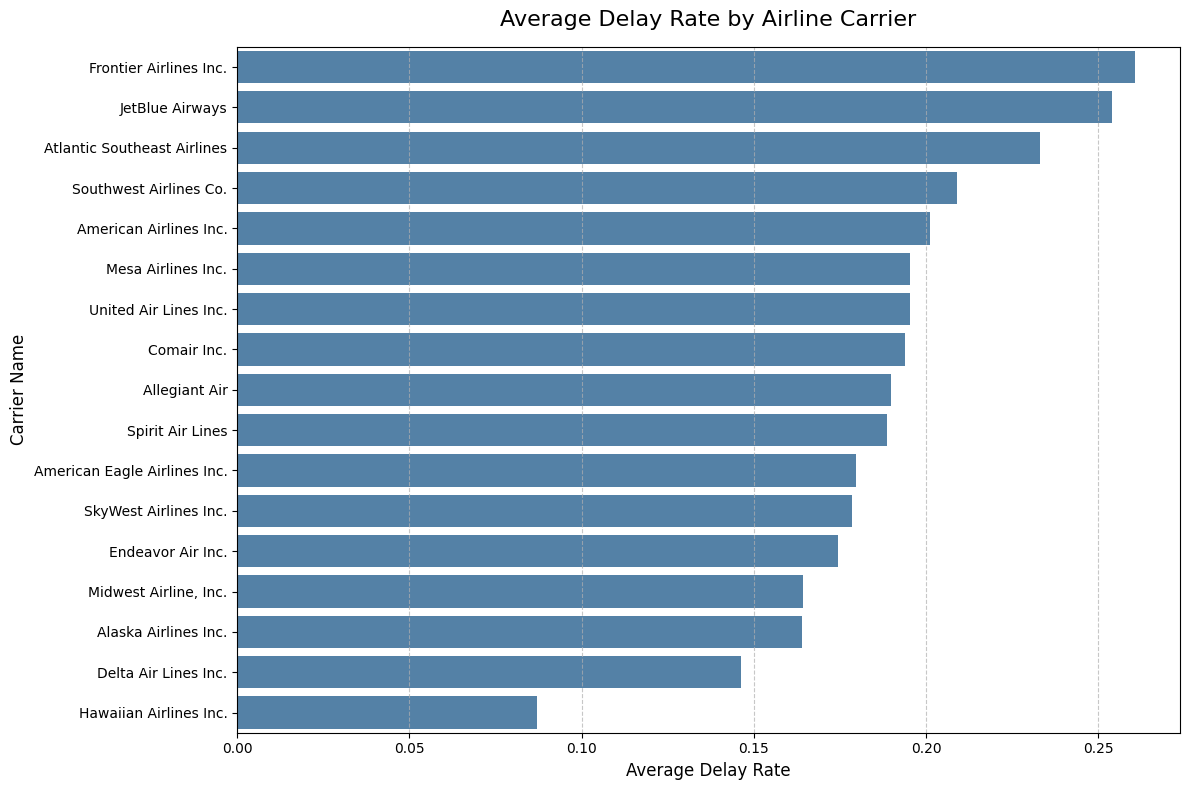

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
carrier_order = df_train.groupby('CARRIER_NAME')['DELAY'].mean().sort_values(ascending=False).index
sns.barplot(
    data=df_train, 
    x='DELAY',           
    y='CARRIER_NAME',    
    order=carrier_order, 
    color='steelblue',
    errorbar=None       
)

plt.title('Average Delay Rate by Airline Carrier', fontsize=16, pad=15)
plt.xlabel('Average Delay Rate', fontsize=12)
plt.ylabel('Carrier Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Airport

In [19]:
print(f"Number of airlines: {len(df_train['DEPARTING_AIRPORT'].unique())}")
print(df_train["DEPARTING_AIRPORT"].value_counts())

Number of airlines: 96
DEPARTING_AIRPORT
Atlanta Municipal                 275230
Chicago O'Hare International      230460
Dallas Fort Worth Regional        207742
Stapleton International           173046
Douglas Municipal                 162162
                                   ...  
Portland International Jetport      2522
Pensacola Regional                  2498
Spokane International               2399
Sanford NAS                         1646
Puerto Rico International             61
Name: count, Length: 96, dtype: int64


## 1.3. Non Categorical Variables

### Latitude and Longitude

Create regions to see if wind varies per region

In [20]:
def assign_region(lat, lon):
    if lat >= 45:        
        return "north"
    elif lat <= 30:      
        return "south"
    else:
        if lon <= -100:  
            return "west"
        else:
            return "east"

df_train["REGION"] = df_train.apply(lambda r: assign_region(r["LATITUDE"], r["LONGITUDE"]), axis=1)
print(df_train["REGION"].value_counts())

REGION
east     2669380
west     1084145
south     630763
north     158055
Name: count, dtype: int64


### Concurrent Flights (discrete)

Maximum value: 109
Minimum value: 1
Mean: 27.84460772777397


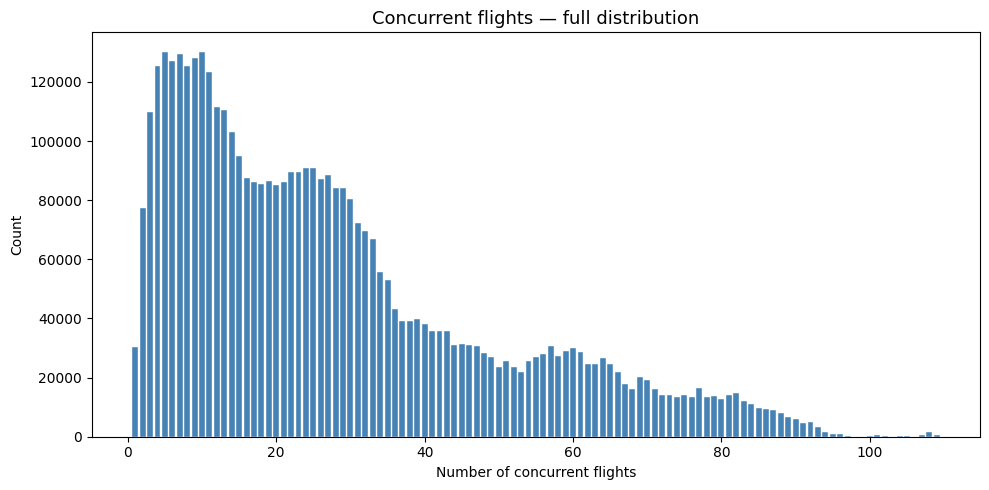

In [21]:
cflights = df_train["CONCURRENT_FLIGHTS"].values

print(f"Maximum value: {df_train['CONCURRENT_FLIGHTS'].max()}")
print(f"Minimum value: {df_train['CONCURRENT_FLIGHTS'].min()}")
print(f"Mean: {df_train['CONCURRENT_FLIGHTS'].mean()}")

values, counts = np.unique(cflights, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(values, counts, color='steelblue', edgecolor='white', linewidth=0.3)
plt.title('Concurrent flights — full distribution', fontsize=13)
plt.xlabel('Number of concurrent flights')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

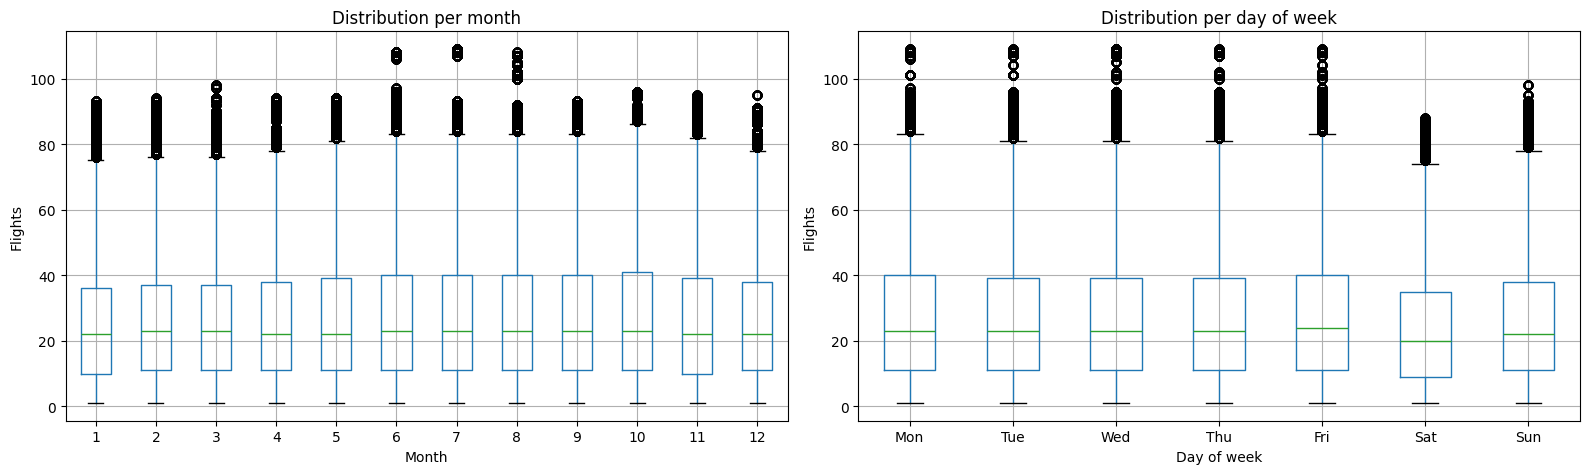

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_train.boxplot(column="CONCURRENT_FLIGHTS", by="MONTH", ax=axes[0])
axes[0].set_title("Distribution per month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Flights")

df_train.boxplot(column="CONCURRENT_FLIGHTS", by="DAY_OF_WEEK", ax=axes[1])
axes[1].set_title("Distribution per day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Flights")
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)

plt.suptitle("")
plt.tight_layout()
plt.show()

Does not vary much per month nor per day of week

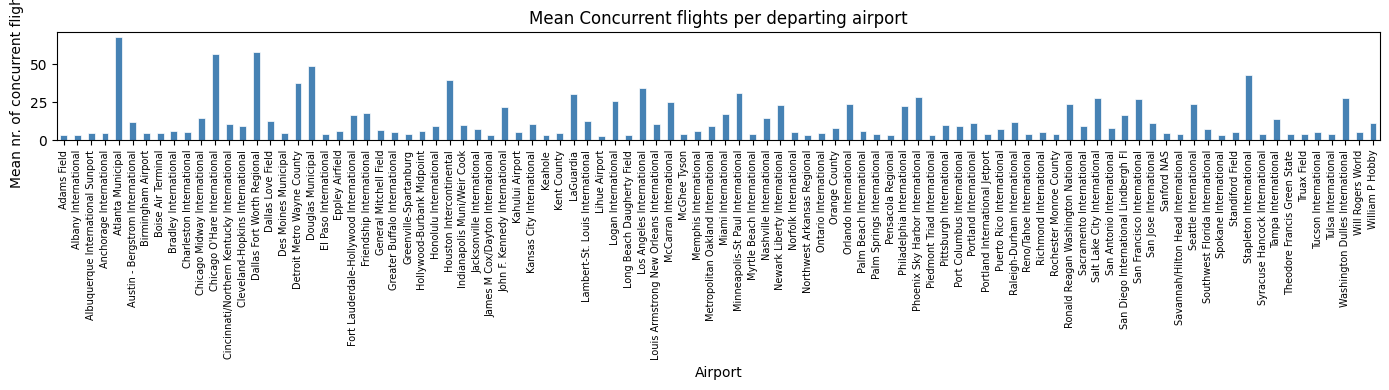

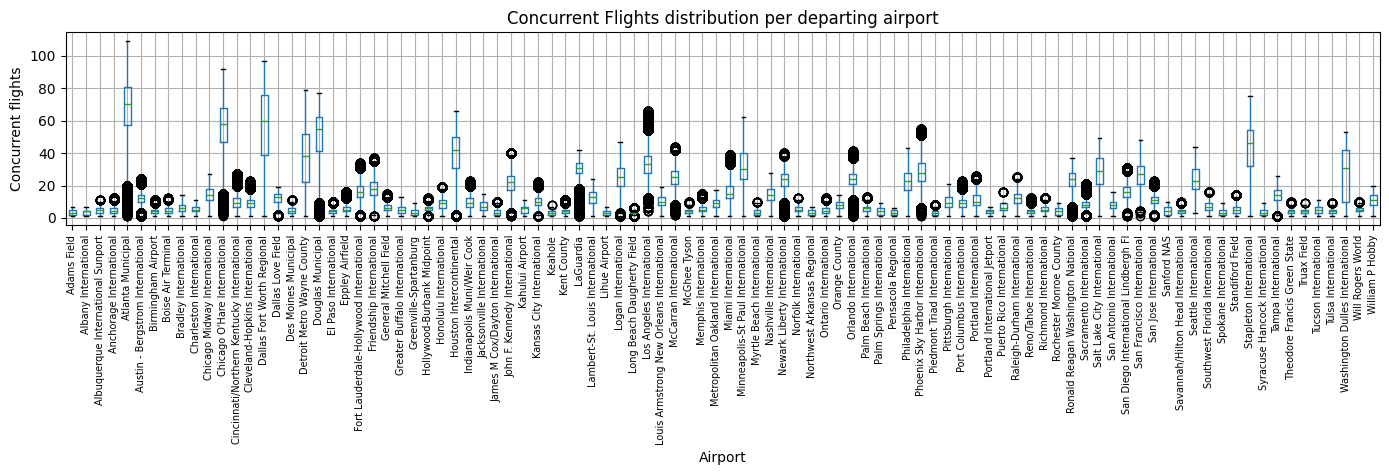

In [23]:
cf_per_airport = df_train.groupby("DEPARTING_AIRPORT")["CONCURRENT_FLIGHTS"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
cf_per_airport.plot(kind="bar", ax=ax, color="steelblue",edgecolor="white", linewidth=0.5)
ax.set_title("Mean Concurrent flights per departing airport")
ax.set_xlabel("Airport")
ax.set_ylabel("Mean nr. of concurrent flights")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

df_train.boxplot(column="CONCURRENT_FLIGHTS", by="DEPARTING_AIRPORT", figsize=(14, 5))
plt.title("Concurrent Flights distribution per departing airport")
plt.suptitle("")
plt.xlabel("Airport")
plt.ylabel("Concurrent flights")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

Kinda varies but too many

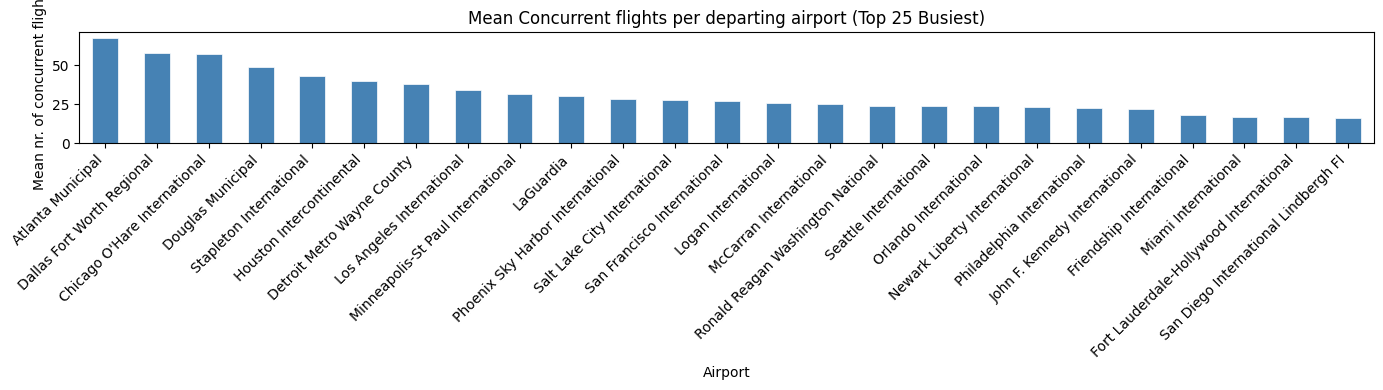

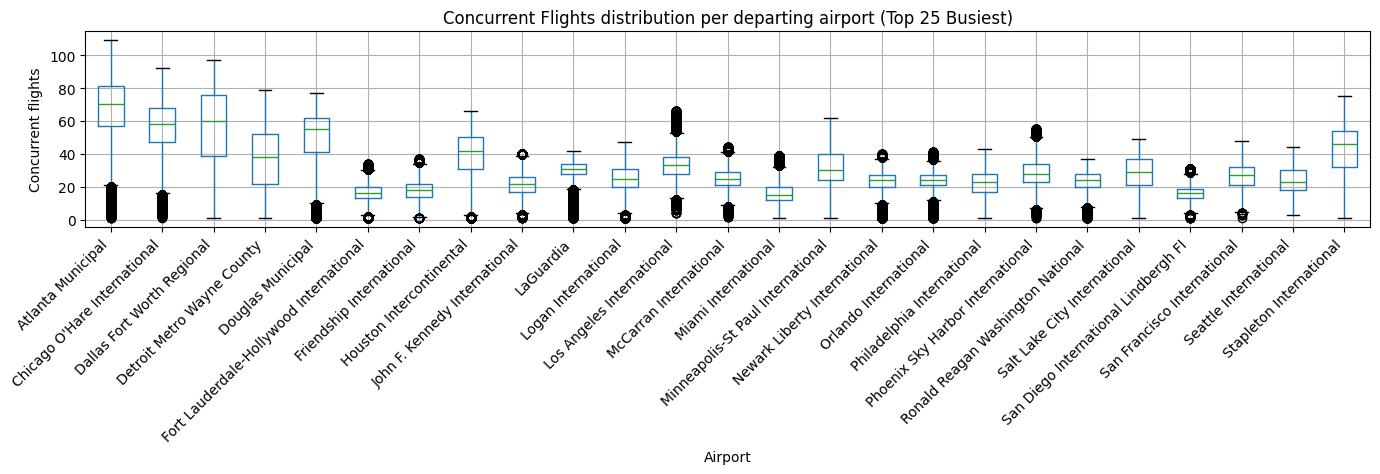

In [24]:
import pandas as pd
from pathlib import Path

if "df_train" not in globals():
    filtered_path = Path("data/train_filter.csv")
    if filtered_path.exists():
        df_train = pd.read_csv(filtered_path)
    else:
        df_original = pd.read_csv("data/train.csv")
        df_train = df_original[["MONTH", "DAY_OF_WEEK", "DEP_DEL15", "CONCURRENT_FLIGHTS", "CARRIER_NAME", "PRCP", "AWND", "DEPARTING_AIRPORT", "DEP_TIME_BLK", "LATITUDE", "LONGITUDE"]].copy()
        df_train = df_train.rename(columns={"DEP_DEL15": "DELAY", "AWND": "WIND"})
        df_train.to_csv(filtered_path, index=False)

# 1. Identify the Top 25 busiest departing airports by total flight volume
top_25_airports = df_train["DEPARTING_AIRPORT"].value_counts().head(25).index

# 2. Filter the dataframe to ONLY include those top 25 airports
df_top25 = df_train[df_train["DEPARTING_AIRPORT"].isin(top_25_airports)]

# 3. Calculate the mean concurrent flights for these filtered airports
# Adding .sort_values(ascending=False) makes the bar chart slope downward nicely!
cf_per_airport_top25 = df_top25.groupby("DEPARTING_AIRPORT")["CONCURRENT_FLIGHTS"].mean().sort_values(ascending=False)

# ==========================================
# GRAPH 1: The Bar Chart
# ==========================================
fig, ax = plt.subplots(figsize=(14, 4))
cf_per_airport_top25.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white", linewidth=0.5)

ax.set_title("Mean Concurrent flights per departing airport (Top 25 Busiest)")
ax.set_xlabel("Airport")
ax.set_ylabel("Mean nr. of concurrent flights")

# Increased font size and changed rotation so it looks perfectly clean
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


# ==========================================
# GRAPH 2: The Box Plot
# ==========================================
# We use df_top25 here instead of df_train!
df_top25.boxplot(column="CONCURRENT_FLIGHTS", by="DEPARTING_AIRPORT", figsize=(14, 5))

plt.title("Concurrent Flights distribution per departing airport (Top 25 Busiest)")
plt.suptitle("")
plt.xlabel("Airport")
plt.ylabel("Concurrent flights")

# Increased font size and changed rotation here as well
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

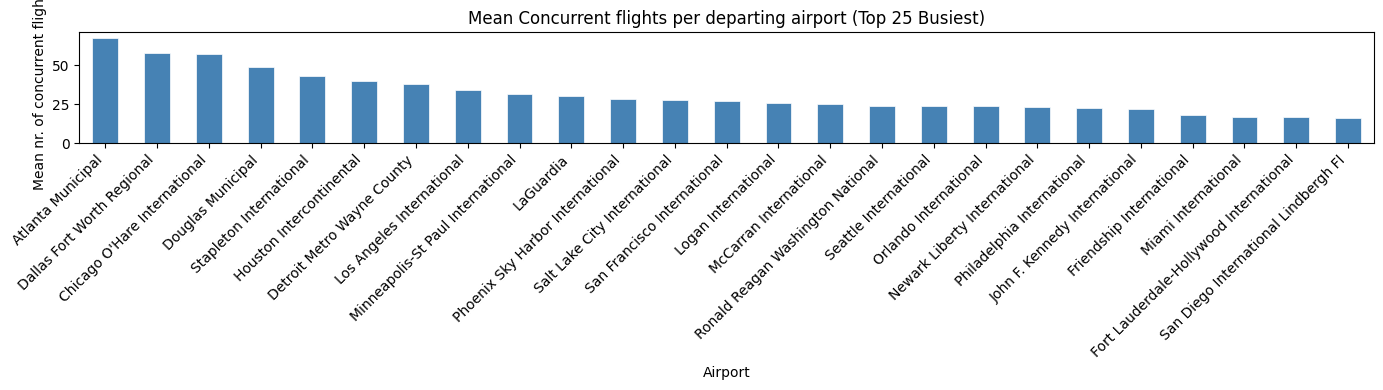

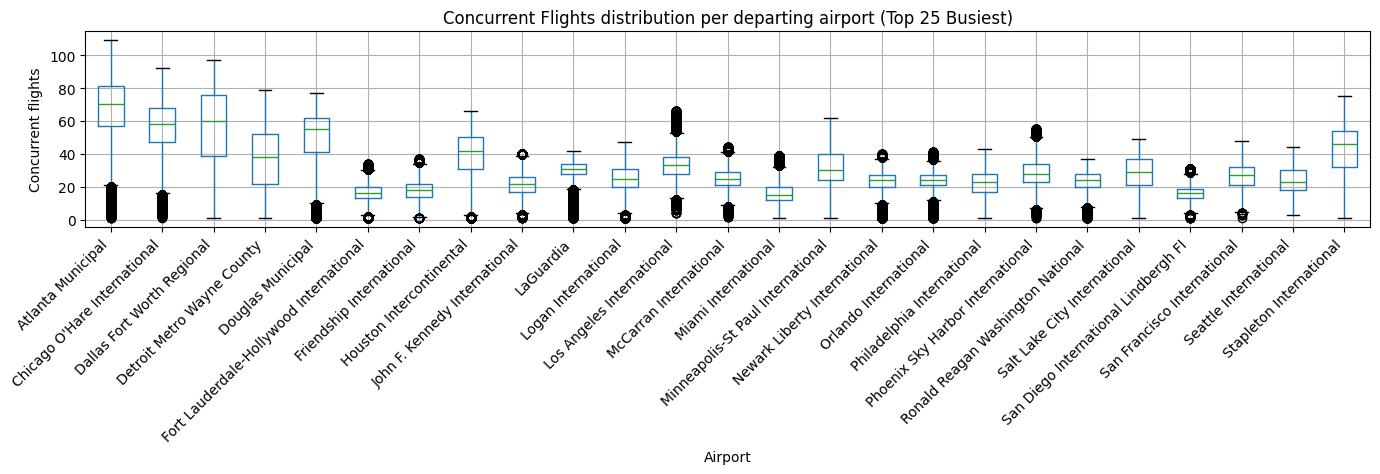

In [25]:
# 1. Identify the Top 25 busiest departing airports by total flight volume
top_25_airports = df_train["DEPARTING_AIRPORT"].value_counts().head(25).index

# 2. Filter the dataframe to ONLY include those top 25 airports
df_top25 = df_train[df_train["DEPARTING_AIRPORT"].isin(top_25_airports)]

# 3. Calculate the mean concurrent flights for these filtered airports
# Adding .sort_values(ascending=False) makes the bar chart slope downward nicely!
cf_per_airport_top25 = df_top25.groupby("DEPARTING_AIRPORT")["CONCURRENT_FLIGHTS"].mean().sort_values(ascending=False)


# ==========================================
# GRAPH 1: The Bar Chart
# ==========================================
fig, ax = plt.subplots(figsize=(14, 4))
cf_per_airport_top25.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white", linewidth=0.5)

ax.set_title("Mean Concurrent flights per departing airport (Top 25 Busiest)")
ax.set_xlabel("Airport")
ax.set_ylabel("Mean nr. of concurrent flights")

# Increased font size and changed rotation so it looks perfectly clean
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


# ==========================================
# GRAPH 2: The Box Plot
# ==========================================
# We use df_top25 here instead of df_train!
df_top25.boxplot(column="CONCURRENT_FLIGHTS", by="DEPARTING_AIRPORT", figsize=(14, 5))

plt.title("Concurrent Flights distribution per departing airport (Top 25 Busiest)")
plt.suptitle("")
plt.xlabel("Airport")
plt.ylabel("Concurrent flights")

# Increased font size and changed rotation here as well
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

volume alone doesn't cause delays, it's the variance at specific airports.

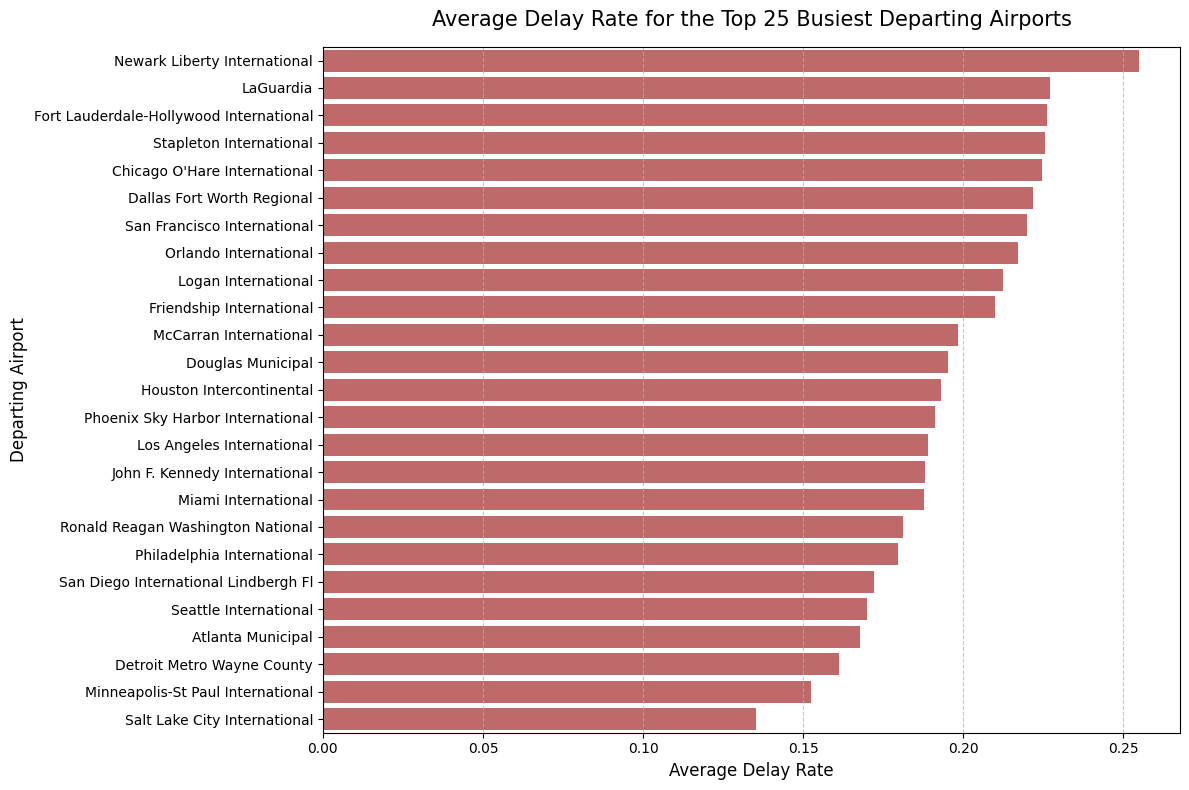

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the Top 25 Busiest Departing Airports
# .value_counts() automatically sorts by volume, so .head(25) grabs the biggest ones
top_25_airports = df_train['DEPARTING_AIRPORT'].value_counts().head(25).index

# 2. Filter the dataframe to ONLY include flights from those top 25 airports
df_top_25 = df_train[df_train['DEPARTING_AIRPORT'].isin(top_25_airports)]

# 3. Calculate the average delay rate for these specific airports and sort them (Worst to Best)
airport_delay_order = df_top_25.groupby('DEPARTING_AIRPORT')['DELAY'].mean().sort_values(ascending=False).index

# 4. Set up the figure size (making it tall enough to comfortably read 25 airport codes)
fig, ax = plt.subplots(figsize=(12, 8))

# 5. Create a Horizontal Bar Plot
sns.barplot(
    data=df_top_25, 
    x='DELAY', 
    y='DEPARTING_AIRPORT', 
    order=airport_delay_order, 
    color='indianred',
    errorbar=None,
    ax=ax
)

# 6. Make it look professional
ax.set_title("Average Delay Rate for the Top 25 Busiest Departing Airports", fontsize=15, pad=15)
ax.set_xlabel("Average Delay Rate", fontsize=12)
ax.set_ylabel("Departing Airport", fontsize=12)

# Add a subtle background grid on the x-axis to easily track the bar lengths
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

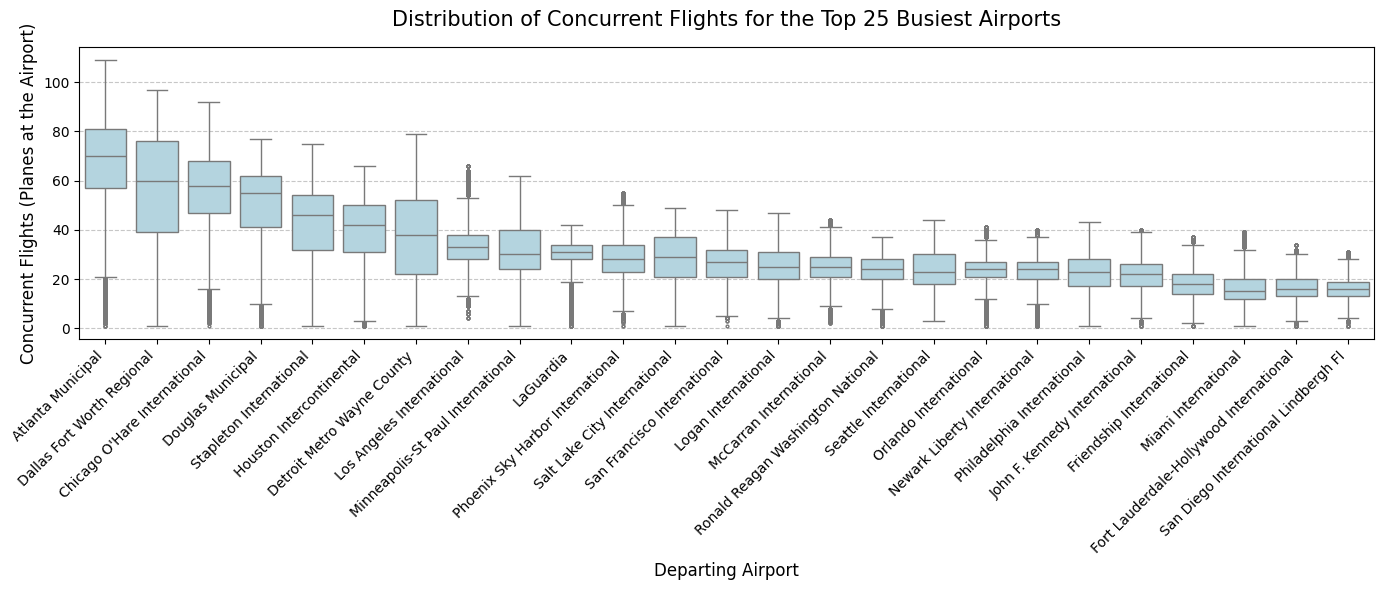

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the Top 25 Busiest Departing Airports
top_25_airports = df_train['DEPARTING_AIRPORT'].value_counts().head(25).index

# 2. Filter the dataframe to ONLY include those top 25 airports
df_top_25 = df_train[df_train['DEPARTING_AIRPORT'].isin(top_25_airports)]

# 3. Calculate the average concurrent flights so we can sort the graph from highest to lowest traffic
cf_order = df_top_25.groupby('DEPARTING_AIRPORT')['CONCURRENT_FLIGHTS'].mean().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top_25, 
    x='DEPARTING_AIRPORT', 
    y='CONCURRENT_FLIGHTS', 
    order=cf_order,  # We use the exact same sorted order so the two graphs match!
    color='lightblue',
    fliersize=2      # Makes the outlier dots smaller
)
plt.title('Distribution of Concurrent Flights for the Top 25 Busiest Airports', fontsize=15, pad=15)
plt.xlabel('Departing Airport', fontsize=12)
plt.ylabel('Concurrent Flights (Planes at the Airport)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
airport_mean = df_train.groupby("DEPARTING_AIRPORT")["CONCURRENT_FLIGHTS"].mean()
small  = airport_mean.quantile(0.33)
large  = airport_mean.quantile(0.67)

def assign_size(airport):
    mean = airport_mean[airport]
    if mean <= small:
        return "small"
    elif mean <= large:
        return "medium"
    else:
        return "large"

df_train["AIRPORT_SIZE"] = df_train["DEPARTING_AIRPORT"].map(lambda a: assign_size(a))
print(df_train["AIRPORT_SIZE"].value_counts())
# Not equally distributed?

AIRPORT_SIZE
large     3375038
medium     864626
small      302679
Name: count, dtype: int64


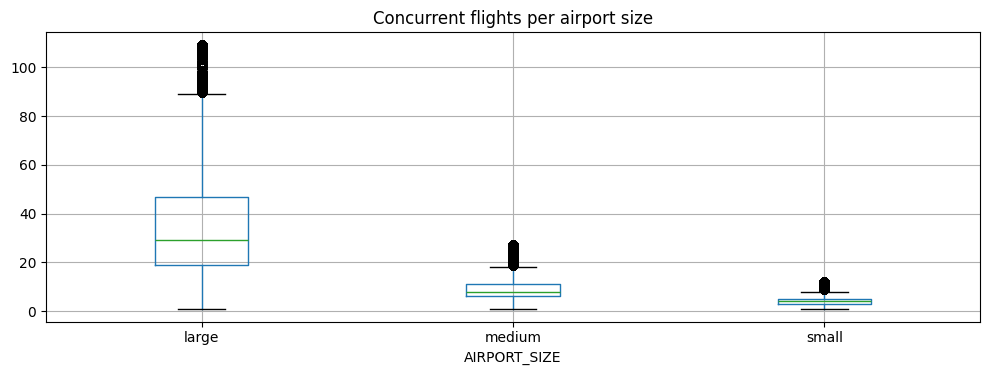

In [29]:
df_train.boxplot(column="CONCURRENT_FLIGHTS", by="AIRPORT_SIZE", figsize=(10, 4))
plt.suptitle("")
plt.title("Concurrent flights per airport size")
plt.tight_layout()
plt.show()

Good

### Precipitation

Maximum value of precipitation: 11.63
Minimum value of precipitation: 0.0
Proportion of zero rain days: 0.7020665326242426
Mean (all days): 0.10368144809848136
Mean (rainy days only): 0.34800201874506764


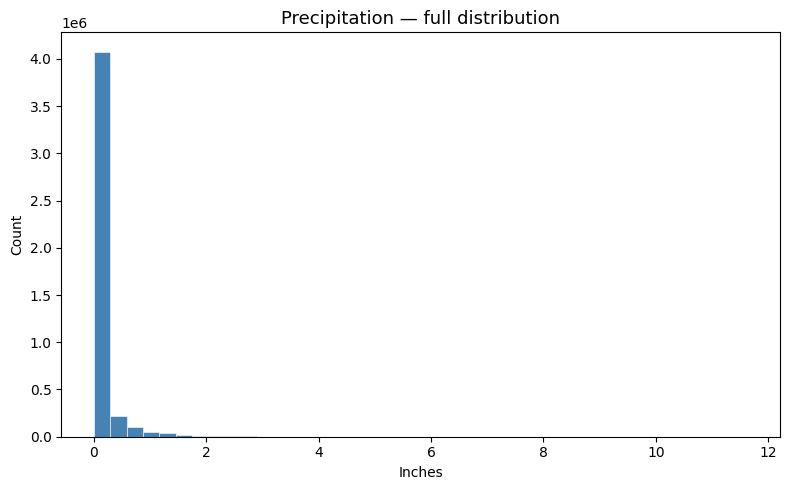

In [31]:
prcp = df_train["PRCP"].values

print(f"Maximum value of precipitation: {df_train['PRCP'].max()}")
print(f"Minimum value of precipitation: {df_train['PRCP'].min()}")
print(f"Proportion of zero rain days: {(df_train['PRCP'] == 0).mean()}")
print(f"Mean (all days): {df_train['PRCP'].mean()}")
print(f"Mean (rainy days only): {df_train[df_train['PRCP'] > 0]['PRCP'].mean()}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(prcp, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_title("Precipitation — full distribution", fontsize=13)
ax.set_xlabel("Inches")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

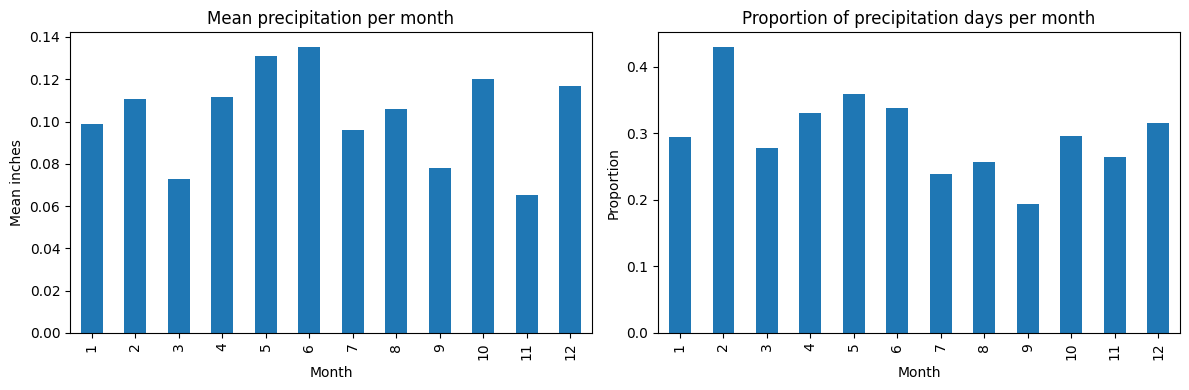

In [32]:
# mean rain per month
rain_per_month = df_train.groupby("MONTH")["PRCP"].mean()

# number of non-zero rain observations per month
nonzero_per_month = df_train[df_train["PRCP"] > 0].groupby("MONTH")["PRCP"].count()

# total observations per month
total_per_month = df_train.groupby("MONTH")["PRCP"].count()

# proportion of rainy days per month
prop_rainy = nonzero_per_month / total_per_month

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rain_per_month.plot(kind="bar", ax=axes[0], title="Mean precipitation per month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean inches")
prop_rainy.plot(kind="bar", ax=axes[1], title="Proportion of precipitation days per month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Proportion")
plt.tight_layout()
plt.show()

Clear variation per month, place it inside month plate

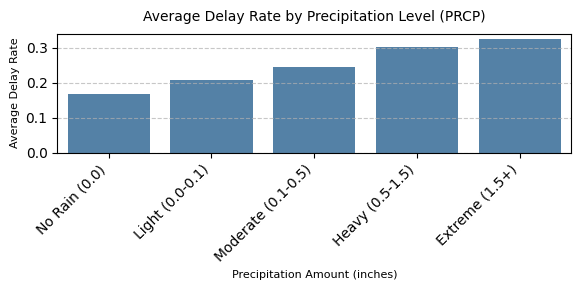

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Create custom weather buckets for Precipitation (PRCP)
# -0.01 to 0.001 captures exactly 0.0 (No Rain)
bins = [-0.01, 0.001, 0.1, 0.5, 1.5, np.inf]
labels = ['No Rain (0.0)', 'Light (0.0-0.1)', 'Moderate (0.1-0.5)', 'Heavy (0.5-1.5)', 'Extreme (1.5+)']

# Create a temporary column for the plotted bins
df_train['PRCP_BINS'] = pd.cut(df_train['PRCP'], bins=bins, labels=labels)

# 2. Calculate the average delay rate per precipitation bucket
prcp_delay = df_train.groupby('PRCP_BINS', observed=False)['DELAY'].mean().reset_index()

# 3. Set up the figure size
fig, ax = plt.subplots(figsize=(6, 3))

# 4. Create a Vertical Bar Plot
sns.barplot(
    data=prcp_delay, 
    x='PRCP_BINS', 
    y='DELAY', 
    color='steelblue',
    ax=ax
)

# 5. Make it look professional
ax.set_title("Average Delay Rate by Precipitation Level (PRCP)", fontsize=10, pad=9)
ax.set_xlabel("Precipitation Amount (inches)", fontsize=8)
ax.set_ylabel("Average Delay Rate", fontsize=8)

# --- THE FIX FOR OVERLAPPING TEXT ---
# Rotate the labels 45 degrees, align them right, and shrink the font to 10
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add a subtle background grid on the y-axis
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Clean up by dropping the temporary column
df_train.drop(columns=['PRCP_BINS'], inplace=True)

### Wind

Maximum value of wind: 33.78
Minimum value of wind: 0.0
Mean (all days): 8.340974151445618


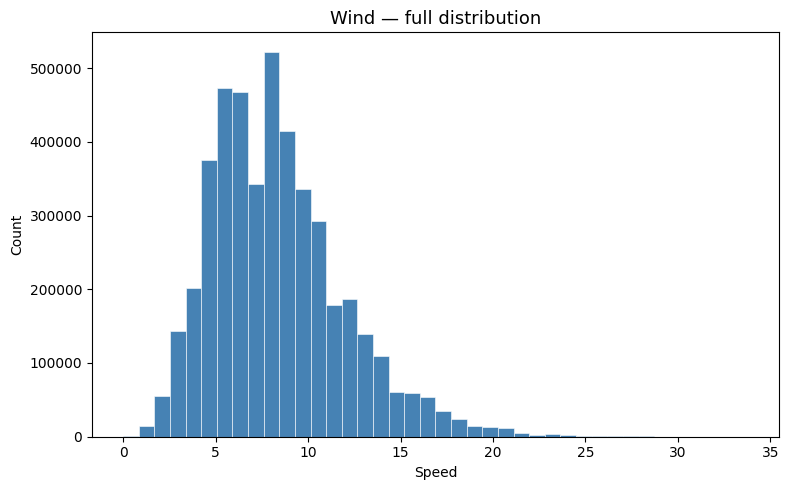

In [35]:
wind = df_train["WIND"].values

print(f"Maximum value of wind: {df_train['WIND'].max()}")
print(f"Minimum value of wind: {df_train['WIND'].min()}")
print(f"Mean (all days): {df_train['WIND'].mean()}")

plt.figure(figsize=(8, 5))
plt.hist(wind, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
plt.title("Wind — full distribution", fontsize=13)
plt.xlabel("Speed")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

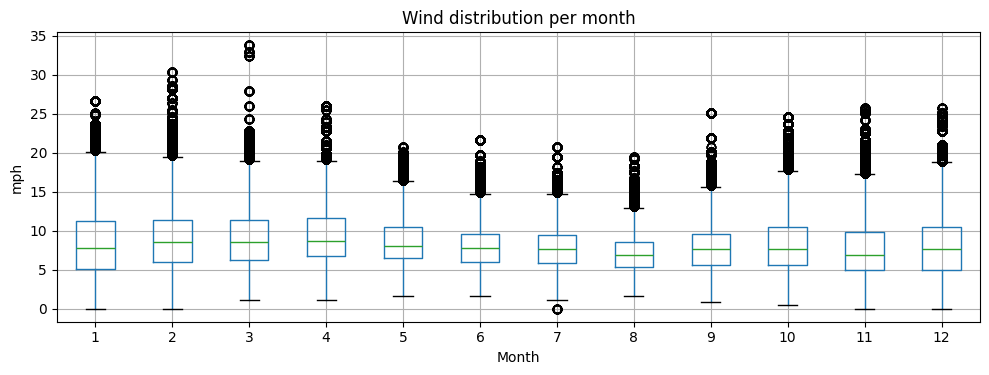

In [36]:
df_train.boxplot(column="WIND", by="MONTH", figsize=(10, 4))
plt.title("Wind distribution per month")
plt.suptitle("")  # removes the default pandas subtitle
plt.xlabel("Month")
plt.ylabel("mph")
plt.tight_layout()
plt.show()

Should we remove it from month plate?

<Figure size 800x500 with 0 Axes>

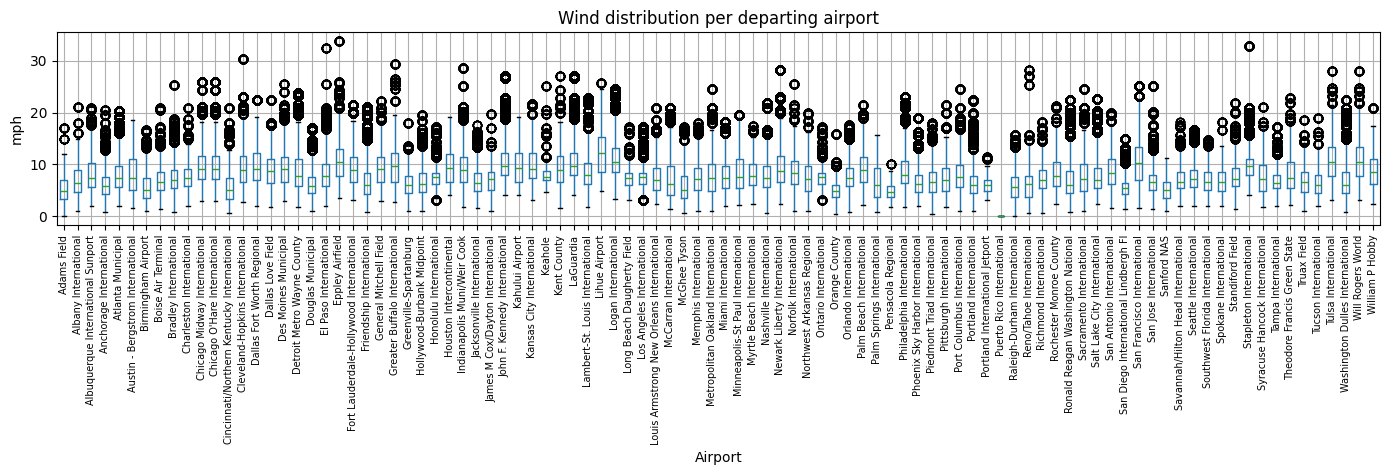

In [37]:
plt.figure(figsize=(8, 5))
df_train.boxplot(column="WIND", by="DEPARTING_AIRPORT", figsize=(14, 5))
plt.title("Wind distribution per departing airport")
plt.suptitle("")
plt.xlabel("Airport")
plt.ylabel("mph")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

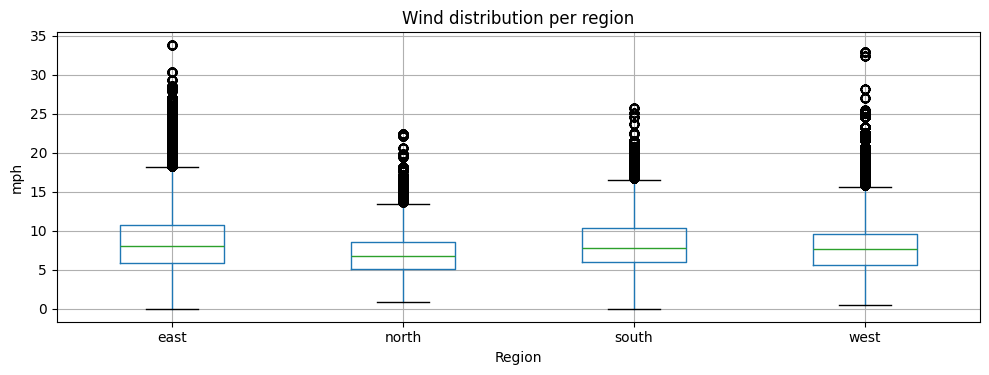

In [38]:
df_train.boxplot(column="WIND", by="REGION", figsize=(10, 4))
plt.suptitle("")
plt.title("Wind distribution per region")
plt.xlabel("Region")
plt.ylabel("mph")
plt.tight_layout()
plt.show()

Not awesome

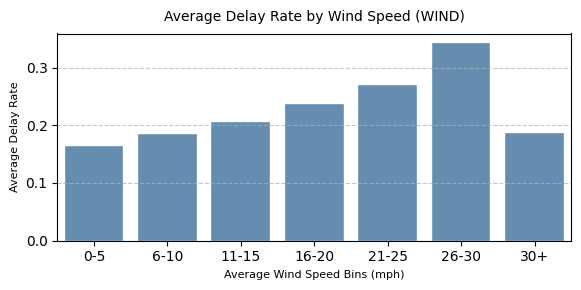

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Create buckets (bins) for Wind Speed
# We group the continuous 'WIND' column into 5 mph increments
bins = [-1, 5, 10, 15, 20, 25, 30, np.inf]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '30+']

# Create a temporary column for the plotted bins
df_train['WIND_BINS'] = pd.cut(df_train['WIND'], bins=bins, labels=labels)

# 2. Calculate the average delay rate per wind bucket
wind_delay = df_train.groupby('WIND_BINS', observed=False)['DELAY'].mean().reset_index()

# 3. Set up the figure size
fig, ax = plt.subplots(figsize=(6, 3))

# 4. Create a Vertical Bar Plot
sns.barplot(
    data=wind_delay, 
    x='WIND_BINS', 
    y='DELAY', 
    color='steelblue',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.9,
    ax=ax
)

# 5. Make it look professional
ax.set_title("Average Delay Rate by Wind Speed (WIND)", fontsize=10, pad=9)
ax.set_xlabel("Average Wind Speed Bins (mph)", fontsize=8)
ax.set_ylabel("Average Delay Rate", fontsize=8)

# Add a subtle background grid on the y-axis to easily track the height
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Optional: Clean up by dropping the temporary column if you don't need it later
df_train.drop(columns=['WIND_BINS'], inplace=True)

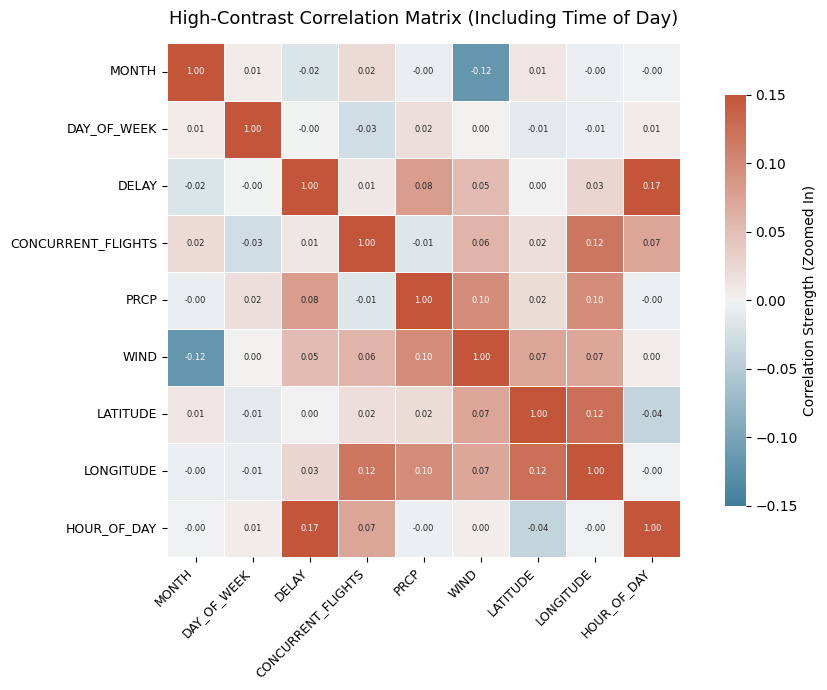

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# FIX 1: FORCE 'TIME OF DAY' TO BE A NUMBER
# ==========================================
# We grab the first 2 characters of the block (e.g., "06" from "0600-0659") and force it into a float
df_train['HOUR_OF_DAY'] = df_train['DEP_TIME_BLK'].astype(str).str[:2].astype(float)

# 1. Select ONLY the numerical columns (This will now safely include HOUR_OF_DAY)
numerical_df = df_train.select_dtypes(include=[np.number])

# 2. Calculate the Pearson correlation matrix
corr_matrix = numerical_df.corr()

# 3. Set up the figure size
plt.figure(figsize=(10, 7))

# 4. Create a professional diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# ==========================================
# FIX 2: CRANK UP THE VISUAL CONTRAST
# ==========================================
# We changed vmax from 1.0 to 0.15 and vmin from -1.0 to -0.15. 
# Now, small numbers will visually POP!
sns.heatmap(
    corr_matrix, 
    cmap=cmap, 
    vmax=0.15,      # High Contrast Max!
    vmin=-0.15,     # High Contrast Min!
    center=0,       
    annot=True,     
    fmt=".2f",      
    square=True,    
    linewidths=.5,  
    cbar_kws={"shrink": .8, "label": "Correlation Strength (Zoomed In)"}, 
    annot_kws={"size": 6}    
)

# 5. Formatting
plt.title("High-Contrast Correlation Matrix (Including Time of Day)", fontsize=13, pad=14)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

# Clean up by dropping the temporary column so it doesn't mess up your later code
df_train.drop(columns=['HOUR_OF_DAY'], inplace=True)

I think it's useful overall to see if some of the relations that we were thinking make sense or not

# 2. Chosen distributions

- DELAY 
- CARRIER_NAME <br>
PLOT DISTRIBUTIONS WITH COMPUTED PARAMETERS TO SEEE


### Precipitation

- Zero inflated distribution for Gamma distribution
- Fit parameters per month from data

In [41]:
rain_thresh=0

rain_params = {}
for month in range(1, 13):
    month_data = df_train[df_train["MONTH"] == month]["PRCP"]

    # proportion of non-precipitation days
    pi_m = (month_data <= rain_thresh).mean()

    # fit gamma on precipitation days only
    wet_days = month_data[month_data > rain_thresh]
    alpha_m, _, beta_m = gamma.fit(wet_days, floc=0)

    rain_params[month] = {
        "pi": torch.tensor(pi_m,    dtype=torch.float32),
        "alpha": torch.tensor(alpha_m, dtype=torch.float32),
        "beta": torch.tensor(beta_m,  dtype=torch.float32)
    }

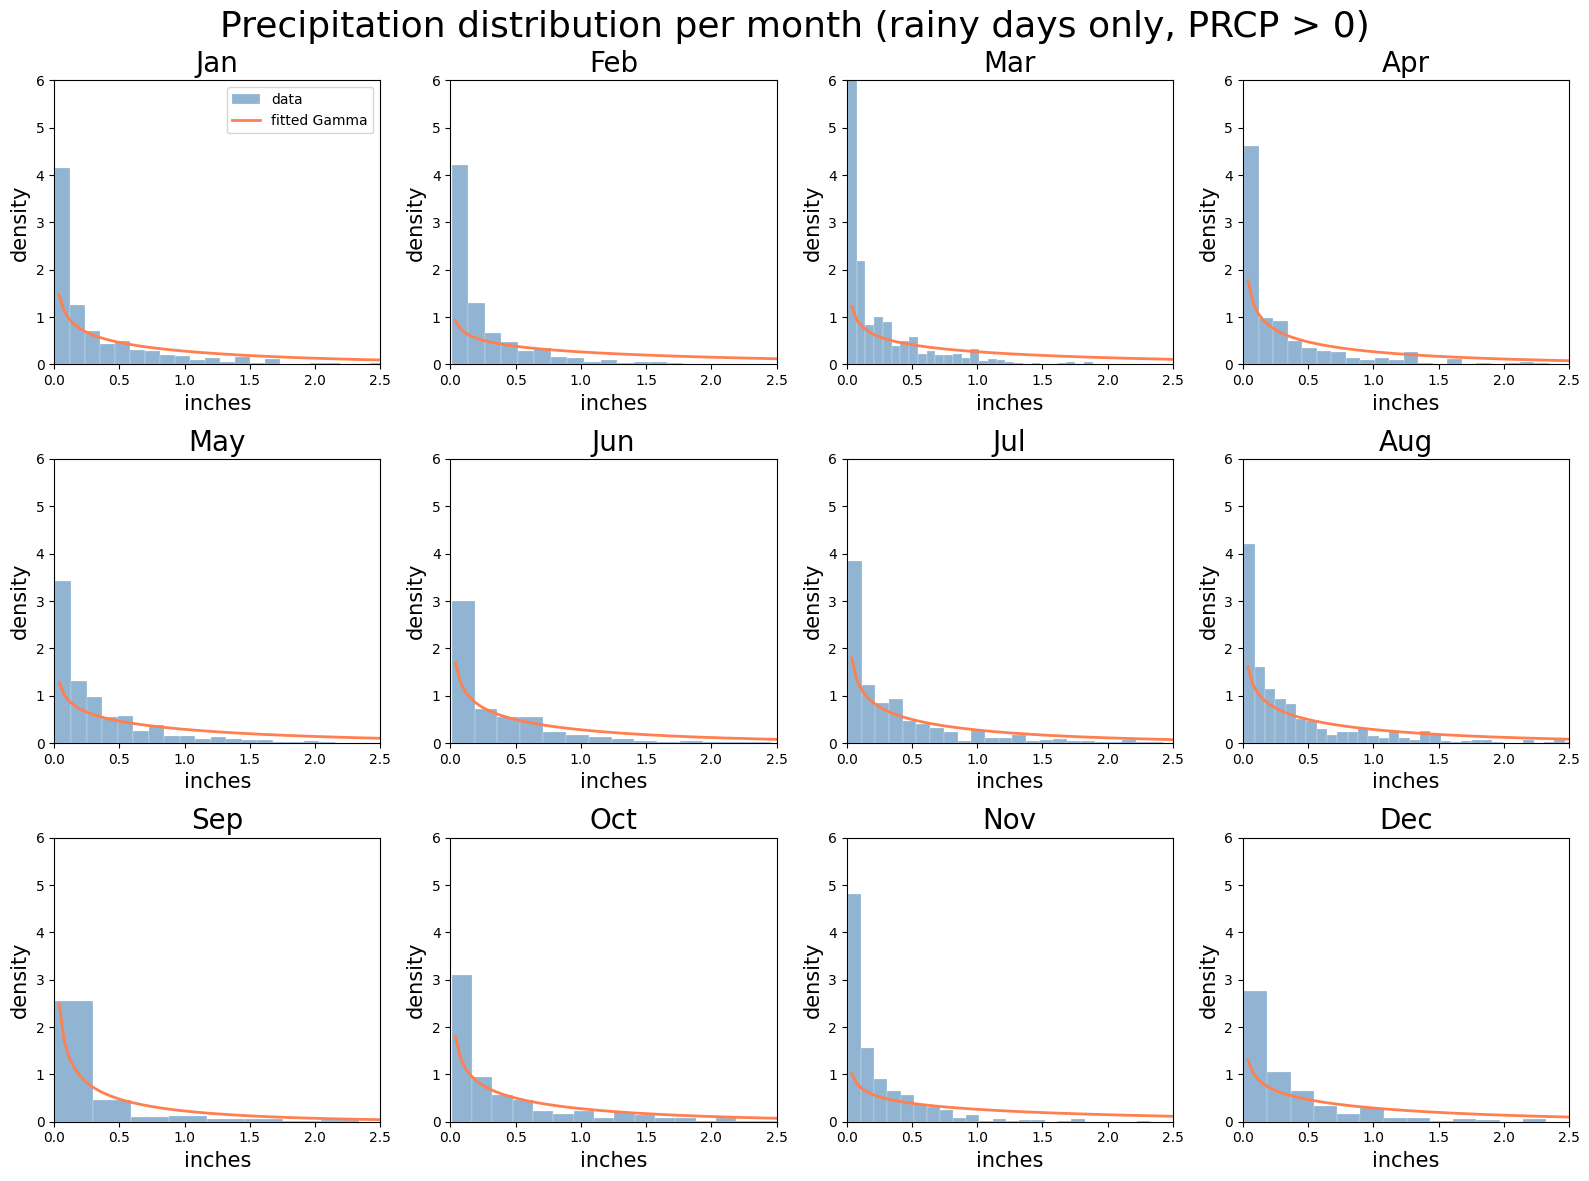

In [67]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

x = np.linspace(0, df_train[df_train["PRCP"] > rain_thresh]["PRCP"].max(), 300)
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for month in range(1, 13):
    ax = axes[month - 1]

    wet_days = df_train[(df_train["MONTH"] == month) & (df_train["PRCP"] > rain_thresh)]["PRCP"].values

    # density true
    ax.hist(wet_days, bins=40, density=True, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.6, label="data")

    alpha = rain_params[month]["alpha"].item()
    beta  = rain_params[month]["beta"].item()
    pdf   = gamma.pdf(x, a=alpha, scale=1/beta)
    ax.plot(x, pdf, color="coral", linewidth=2, label="fitted Gamma")

    ax.set_xlim(0, 2.5)
    ax.set_ylim(0, 6)
    ax.set_title(month_names[month - 1], fontsize=20)
    ax.set_xlabel("inches", fontsize=15)
    ax.set_ylabel("density", fontsize=15)

axes[0].legend()
plt.suptitle(f"Precipitation distribution per month (rainy days only, PRCP > {rain_thresh})", fontsize=26)
plt.tight_layout()
plt.show()

Good distribution: fix parameter or strong prior?

### Wind

- Weibull distribution, used a lot to model wind speed
- Use global, doesnt vary with other variable 
- maybe set a prior so it can be learned? the problem is then should we also set the others? we can do it if we set strong prior

**Global (per nothing, only inside observation plate)**

In [43]:
wind_global = df_train["WIND"].values

shape, _, scale = weibull_min.fit(wind_global, floc=0)

wind_params_global = {
    "shape": torch.tensor(shape, dtype=torch.float32),
    "scale": torch.tensor(scale, dtype=torch.float32)
}

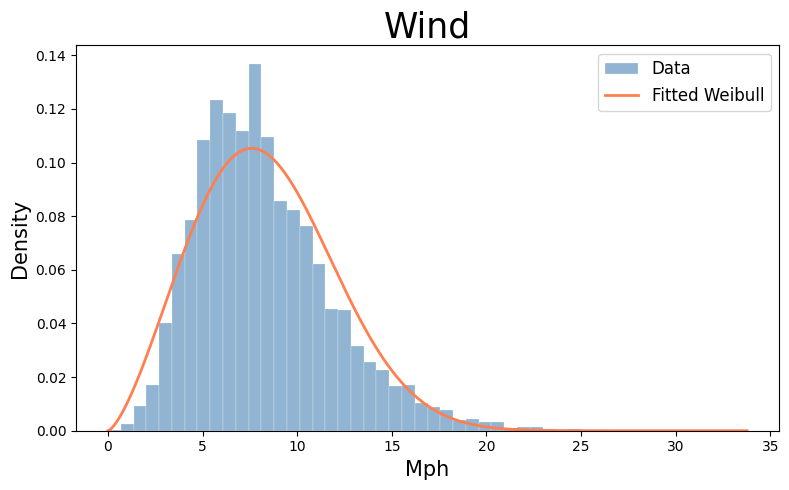

In [80]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(wind_global, bins=50, density=True, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.6, label="Data")

x = np.linspace(0, wind_global.max(), 300)
shape = wind_params_global["shape"].item()
scale = wind_params_global["scale"].item()
pdf = weibull_min.pdf(x, c=shape, scale=scale, loc=0)
ax.plot(x, pdf, color="coral", linewidth=2, label="Fitted Weibull")

ax.set_title("Wind", fontsize=25)
ax.set_xlabel("Mph", fontsize=15)
ax.set_ylabel("Density", fontsize=15)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

Not awesome

**Per month**

In [45]:
wind_params_month = {}
for month in range(1, 13):
    month_data = df_train[df_train["MONTH"] == month]["WIND"].values

    shape, _, scale = weibull_min.fit(month_data, floc=0)

    wind_params_month[month] = {
        "shape": torch.tensor(shape, dtype=torch.float32),
        "scale": torch.tensor(scale, dtype=torch.float32)
    }

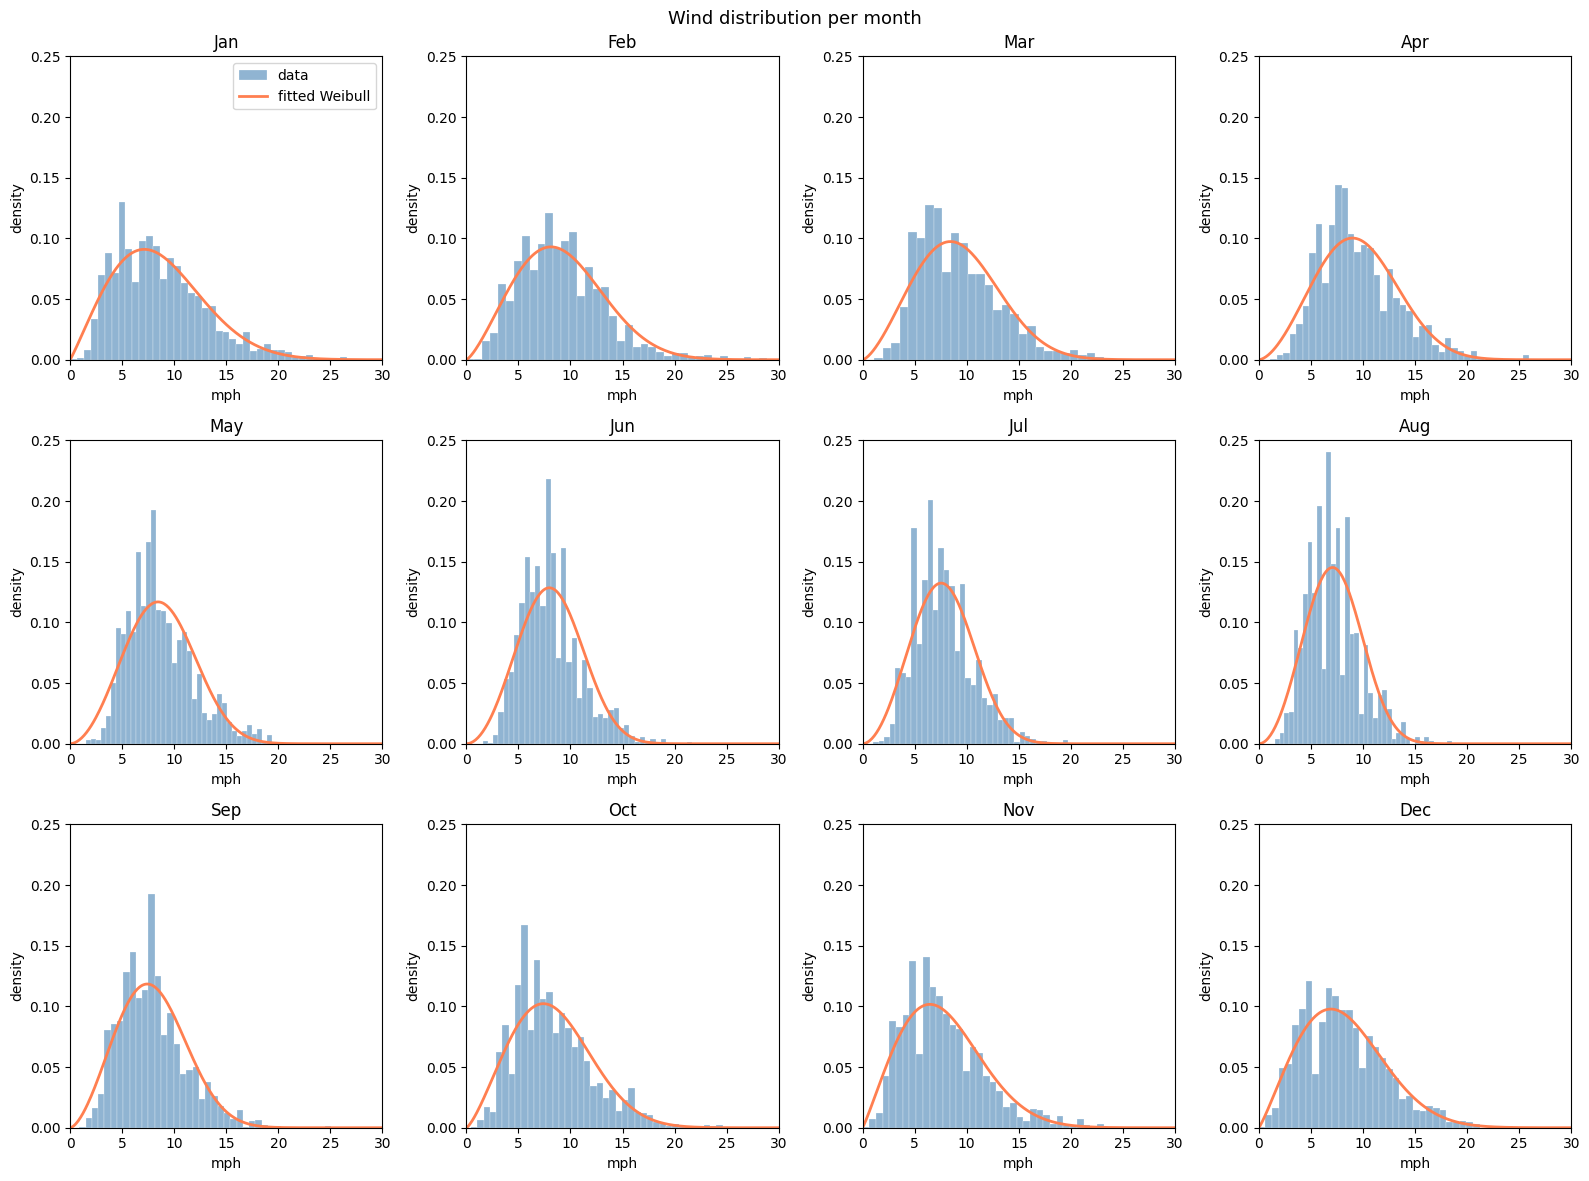

In [70]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

x = np.linspace(0, df_train["WIND"].max(), 300)

for month in range(1, 13):
    ax = axes[month - 1]

    month_data = df_train[df_train["MONTH"] == month]["WIND"].values

    ax.hist(month_data, bins=40, density=True, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.6, label="data")

    shape = wind_params_month[month]["shape"].item()
    scale = wind_params_month[month]["scale"].item()
    pdf   = weibull_min.pdf(x, c=shape, scale=scale, loc=0)
    ax.plot(x, pdf, color="coral", linewidth=2, label="fitted Weibull")

    ax.set_xlim(0, 30)
    ax.set_ylim(0, 0.25)
    ax.set_title(month_names[month - 1])
    ax.set_xlabel("mph")
    ax.set_ylabel("density")

axes[0].legend()
plt.suptitle("Wind distribution per month", fontsize=13)
plt.tight_layout()
plt.show()

- curve peaks too late and too smoothly in every month
- left side (1-5) is always lower than it should
- multi peak around 5 9 in every single month

**Per region**

In [47]:
wind_params_region = {}
for region in sorted(df_train['REGION'].unique()):
    region_data = df_train[df_train['REGION'] == region]['WIND'].values
    shape, _, scale = weibull_min.fit(region_data, floc=0)
    wind_params_region[region] = {
        'shape': torch.tensor(shape, dtype=torch.float32),
        'scale': torch.tensor(scale, dtype=torch.float32)
    }

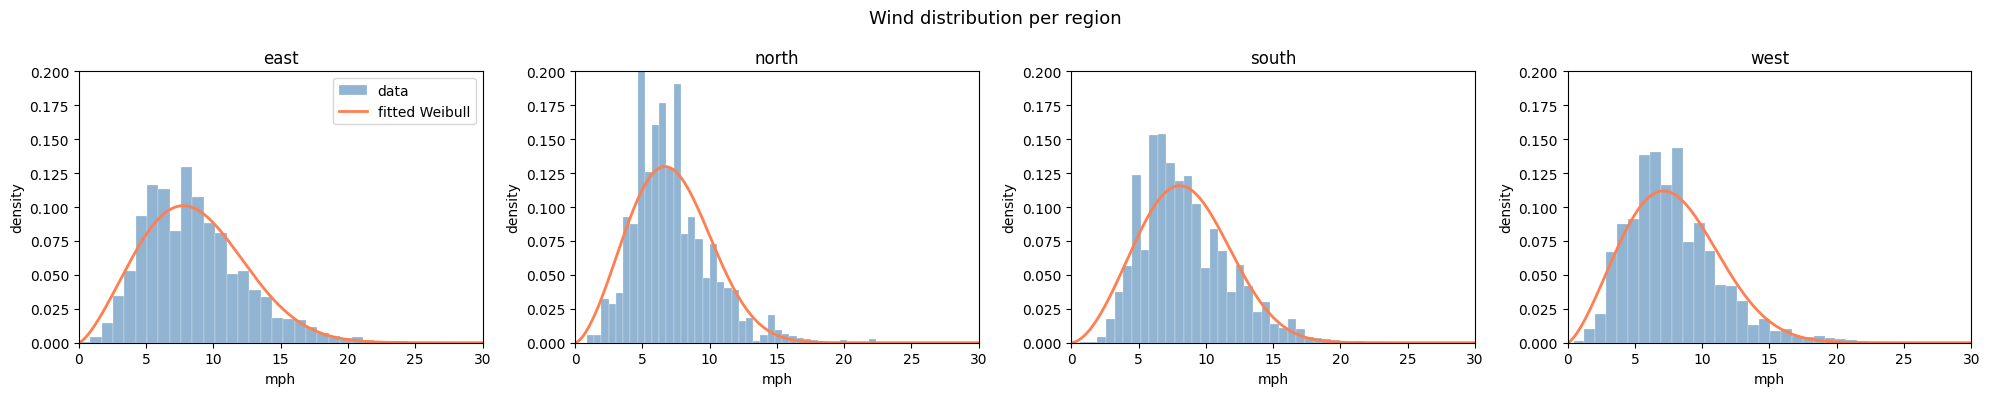

In [72]:
regions = sorted(df_train['REGION'].unique())
n = len(regions)

fig, axes = plt.subplots(1, n, figsize=(5*n, 4))

x = np.linspace(0, df_train['WIND'].max(), 300)

for i, region in enumerate(regions):
    ax = axes[i]

    region_data = df_train[df_train['REGION'] == region]['WIND'].values

    ax.hist(region_data, bins=40, density=True, color='steelblue',
            edgecolor='white', linewidth=0.3, alpha=0.6, label='data')

    shape = wind_params_region[region]['shape'].item()
    scale = wind_params_region[region]['scale'].item()
    pdf   = weibull_min.pdf(x, c=shape, scale=scale, loc=0)
    ax.plot(x, pdf, color='coral', linewidth=2, label='fitted Weibull')

    ax.set_xlim(0, 30)
    ax.set_ylim(0, 0.20)
    ax.set_title(region)
    ax.set_xlabel('mph')
    ax.set_ylabel('density')

axes[0].legend()
plt.suptitle('Wind distribution per region', fontsize=13)
plt.tight_layout()
plt.show()

No good stratification, just use global?

### Concurrent flights

- Negative Binomial

In [49]:
flights_global = df_train["CONCURRENT_FLIGHTS"].values

mean = flights_global.mean()
var  = flights_global.var()

p_mom = mean / var
r_mom = mean * p_mom / (1 - p_mom)

concurrent_params = {
    "r": torch.tensor(r_mom, dtype=torch.float32),
    "p": torch.tensor(p_mom, dtype=torch.float32)
}

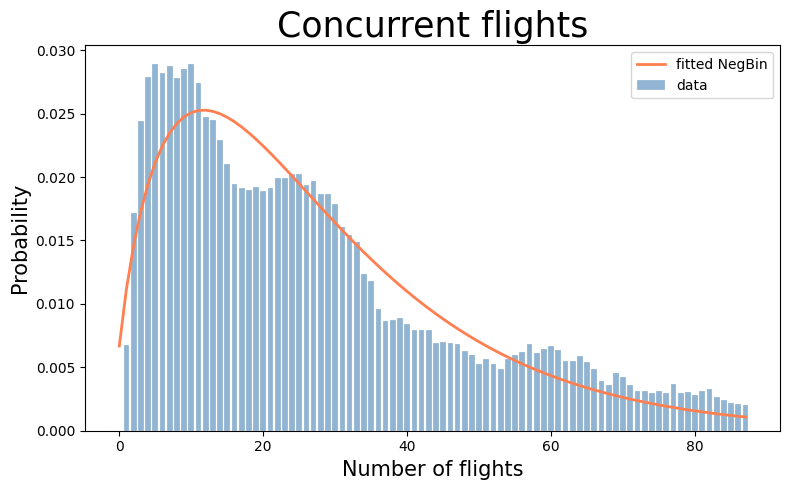

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))

max_flights = int(np.percentile(flights_global, 99))
counts = np.bincount(flights_global[flights_global <= max_flights])
probs  = counts / counts.sum()
ax.bar(range(len(probs)), probs, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.6, label="data")

r = concurrent_params["r"].item()
p = concurrent_params["p"].item()
k = np.arange(0, max_flights + 1)
pmf = nbinom.pmf(k, n=r, p=p)
ax.plot(k, pmf, color="coral", linewidth=2, label="fitted NegBin")

ax.set_title("Concurrent flights", fontsize=25)
ax.set_xlabel("Number of flights", fontsize=15)
ax.set_ylabel("Probability", fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

In [51]:
concurrent_params_size = {}
for size in ['small', 'medium', 'large']:
    size_data = df_train[df_train['AIRPORT_SIZE'] == size]['CONCURRENT_FLIGHTS'].values

    mean = size_data.mean()
    var  = size_data.var()

    p_mom = mean / var
    r_mom = mean * p_mom / (1 - p_mom)

    concurrent_params_size[size] = {
        'r': torch.tensor(r_mom, dtype=torch.float32),
        'p': torch.tensor(p_mom, dtype=torch.float32)
    }

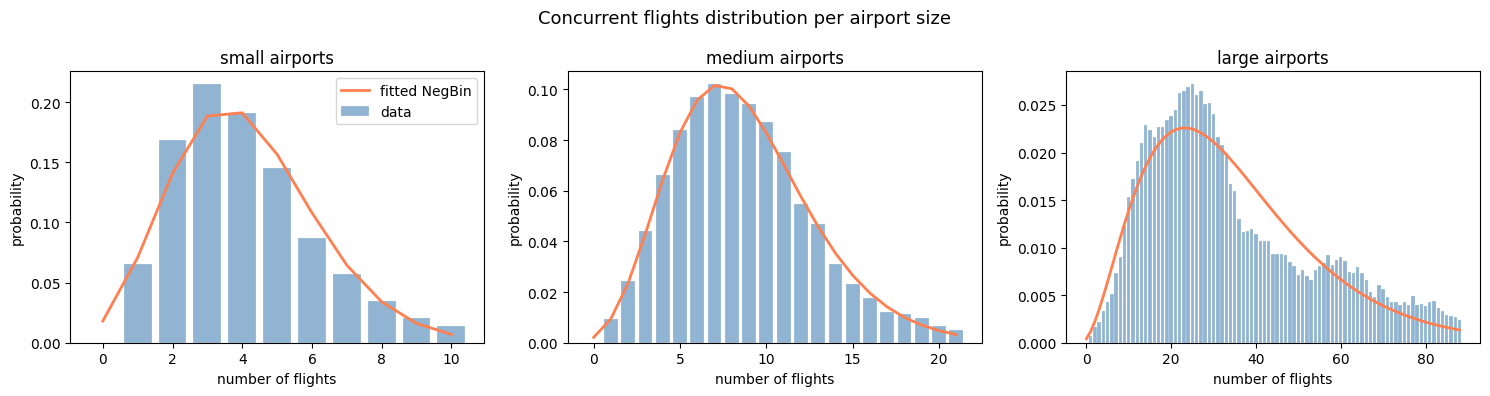

In [76]:
sizes = ['small', 'medium', 'large']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, size in enumerate(sizes):
    ax = axes[i]

    size_data = df_train[df_train['AIRPORT_SIZE'] == size]['CONCURRENT_FLIGHTS'].values

    max_flights = int(np.percentile(size_data, 99))
    counts = np.bincount(size_data[size_data <= max_flights])
    probs  = counts / counts.sum()
    ax.bar(range(len(probs)), probs, color='steelblue',edgecolor='white', linewidth=0.3, alpha=0.6, label='data')

    r = concurrent_params_size[size]['r'].item()
    p = concurrent_params_size[size]['p'].item()
    k = np.arange(0, max_flights + 1)
    pmf = nbinom.pmf(k, n=r, p=p)
    ax.plot(k, pmf, color='coral', linewidth=2, label='fitted NegBin')
    
    ax.set_title(f'{size} airports')
    ax.set_xlabel('number of flights')
    ax.set_ylabel('probability')

axes[0].legend()
plt.suptitle('Concurrent flights distribution per airport size', fontsize=13)
plt.tight_layout()
plt.show()

# 3. Model

Now it is time to make the model using pyro

In [53]:
def my_model(x, delay_obs, carrier_obs, percipitation_obs, wind_obs, concurrent_flights_obs):
    beta = pyro.sample("beta", pyro.distributions.Normal(0., 1.))
    with pyro.plate("N", len(delay_obs)):
        carrier = pyro.sample("carrier", pyro.distributions.Normal(0., 1.), obs=carrier_obs) # Use the carrier delay instead? (check grouping first)
        with pyro.plate("M", 12): # 12 months
            percipitation = pyro.sample("percipitation", pyro.distributions.Normal(0., 1.), obs=percipitation_obs)
            
            wind = pyro.sample("wind", pyro.distributions.Weibull(1., 1.), obs=wind_obs)
            with pyro.plate("DN", 7): # 7 days a week
                concurrent_flights = pyro.sample("concurrent_flights", pyro.distributions.NegativeBinomial(1., 1.), obs=concurrent_flights_obs)

        expected_delay = beta * x + carrier + percipitation + wind + concurrent_flights # Figure out how to combine these properly (additive? multiplicative? interaction terms?)
        delay = pyro.sample("delay", pyro.distributions.Bernoulli(torch.tensor(0.5)), obs=delay_obs) # set to 50/50 chance for now
    return delay, expected_delay